,Stage,Count,Overall Conversion %,Step Conversion %
0,Inquiries,1500,100.00,100.00
1,Consultations Booked,984,65.60,65.60
2,Quotes Shared,561,37.40,57.01
3,Treatments Completed,554,36.93,98.75


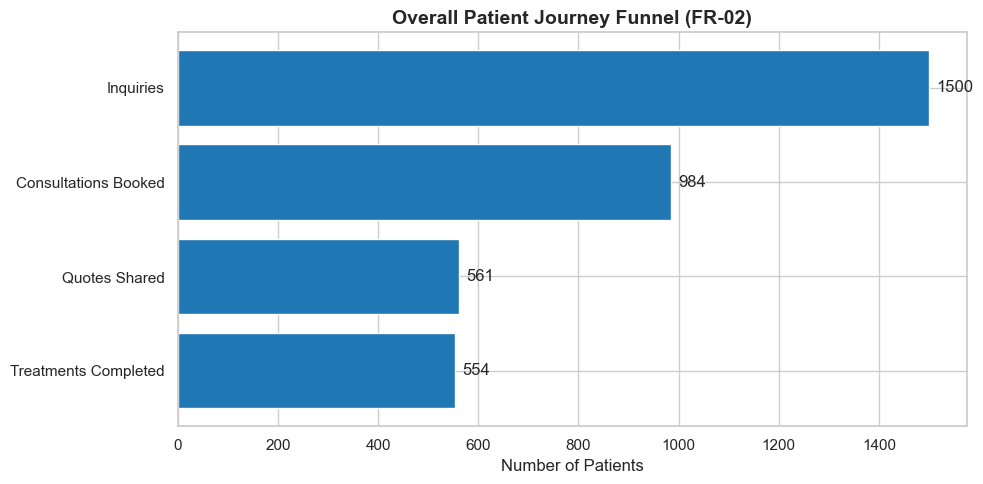

,Reason for Drop-off,Patient Count,Percentage %
0,No follow-up,66,18.86
1,Cost concern,62,17.71
2,Response delay,60,17.14
3,Chose competitor,45,12.86
4,Travel constraints,30,8.57
5,Documentation pending,26,7.43
6,Insurance/payment issue,24,6.86
7,Medical ineligibility,21,6.00
8,Low intent,13,3.71
9,Language barrier,3,0.86


,lead_source,Inquiries,Completed,Avg_Intent,Conversion Rate %
1,Email,238,95,60.179832,39.92
5,WhatsApp,272,105,63.319853,38.60
2,Phone,244,94,62.462705,38.52
0,Chatbot,254,93,61.075984,36.61
4,Web Form,246,85,59.834553,34.55
3,Referral Partner,246,82,64.234146,33.33


In [5]:
# Cell 1: Data Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pj = pd.read_csv('patient_journey.csv')
cl = pd.read_csv('communication_logs.csv')
to = pd.read_csv('treatment_outcomes.csv')

# Cell 2: Stage-by-Stage Funnel Metrics & Charting
total_inquiries = len(pj)
funnel_df = pd.DataFrame({
    'Stage': ['Inquiries', 'Consultations Booked', 'Quotes Shared', 'Treatments Completed'],
    'Count': [total_inquiries, pj['consultation_booked'].sum(), pj['quote_shared'].sum(), pj['treatment_completed'].sum()]
})
funnel_df['Overall Conversion %'] = (funnel_df['Count'] / total_inquiries * 100).round(2)
funnel_df['Step Conversion %'] = (funnel_df['Count'] / funnel_df['Count'].shift(1).fillna(total_inquiries) * 100).round(2)

display(funnel_df)

# Horizontal Funnel Chart
plt.figure(figsize=(10, 5))
bars = plt.barh(funnel_df['Stage'][::-1], funnel_df['Count'][::-1], color='#1f77b4')
plt.title('Overall Patient Journey Funnel (FR-02)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
for bar in bars:
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, f"{int(bar.get_width())}", va='center')
plt.tight_layout()
plt.show()

# Cell 3: Attrition & Drop-off Analysis
drop_reasons = pj['reason_for_drop_off'].value_counts().reset_index()
drop_reasons.columns = ['Reason for Drop-off', 'Patient Count']
drop_reasons['Percentage %'] = (drop_reasons['Patient Count'] / drop_reasons['Patient Count'].sum() * 100).round(2)

display(drop_reasons)

# Cell 4: Lead Source Performance
lead_perf = pj.groupby('lead_source').agg(
    Inquiries=('patient_id', 'count'),
    Completed=('treatment_completed', 'sum'),
    Avg_Intent=('intent_score', 'mean')
).reset_index()
lead_perf['Conversion Rate %'] = (lead_perf['Completed'] / lead_perf['Inquiries'] * 100).round(2)
display(lead_perf.sort_values(by='Conversion Rate %', ascending=False))